# EDA & Training — Phân khúc giá điện thoại

Notebook khám phá dữ liệu và thử nghiệm huấn luyện. Đặt file dữ liệu vào `data/raw/`, sau xử lý lưu vào `data/processed/`.

In [1]:
import sys
from pathlib import Path

import pandas as pd

# Thêm thư mục gốc project vào path để import src
ROOT = Path.cwd().resolve().parent
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

from src import evaluate, model

RAW = ROOT / "data" / "raw"
PROCESSED = ROOT / "data" / "processed"
print("ROOT:", ROOT)

ROOT: Y:\python


=== df.info() ===
<class 'pandas.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   battery_power  2000 non-null   int64  
 1   blue           2000 non-null   int64  
 2   clock_speed    2000 non-null   float64
 3   dual_sim       2000 non-null   int64  
 4   fc             2000 non-null   int64  
 5   four_g         2000 non-null   int64  
 6   int_memory     2000 non-null   int64  
 7   m_dep          2000 non-null   float64
 8   mobile_wt      2000 non-null   int64  
 9   n_cores        2000 non-null   int64  
 10  pc             2000 non-null   int64  
 11  px_height      2000 non-null   int64  
 12  px_width       2000 non-null   int64  
 13  ram            2000 non-null   int64  
 14  sc_h           2000 non-null   int64  
 15  sc_w           2000 non-null   int64  
 16  talk_time      2000 non-null   int64  
 17  three_g        2000 non-null   int64  
 18  t

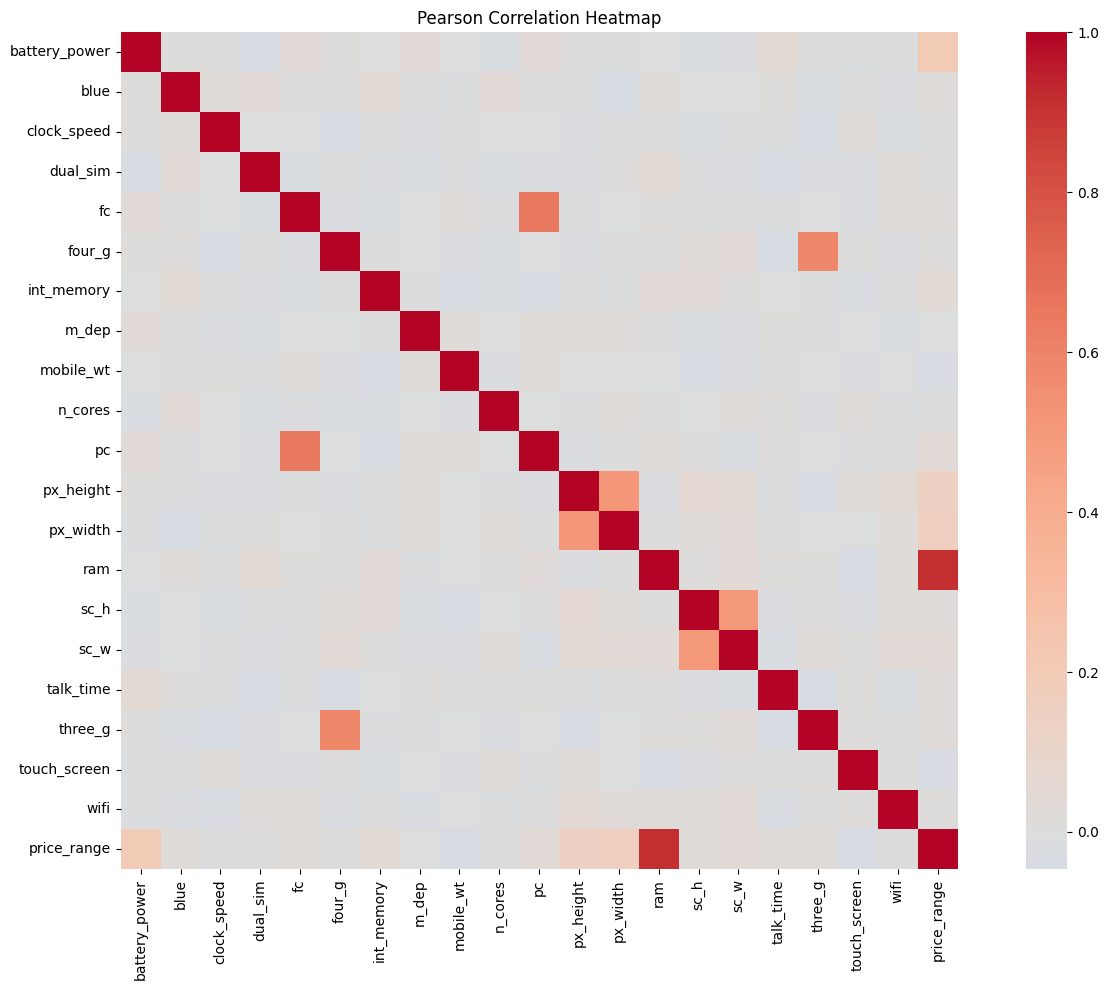


=== Top 3 features tương quan cao nhất với price_range (|corr|) ===
- ram: corr = 0.9170, |corr| = 0.9170
- battery_power: corr = 0.2007, |corr| = 0.2007
- px_width: corr = 0.1658, |corr| = 0.1658


In [2]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1) Đọc dữ liệu train.csv (đặt file tại data/raw/train.csv)
df = pd.read_csv(RAW / "train.csv")

# 2) Thống kê cơ bản
print("=== df.info() ===")
df.info()

print("\n=== df.describe() ===")
print(df.describe())

# 3) Missing values và duplicate rows
print("\n=== Missing values theo cột ===")
missing_counts = df.isna().sum().sort_values(ascending=False)
print(missing_counts)

duplicate_count = df.duplicated().sum()
print(f"\n=== Số dòng trùng lặp ===\n{duplicate_count}")

# 4) Pearson Correlation toàn bộ dataframe
corr_matrix = df.corr(method="pearson", numeric_only=True)
print("\n=== Pearson Correlation Matrix ===")
print(corr_matrix)

# 5) Heatmap + Top 3 feature tương quan cao nhất với price_range
plt.figure(figsize=(14, 10))
sns.heatmap(corr_matrix, cmap="coolwarm", center=0, square=True)
plt.title("Pearson Correlation Heatmap")
plt.tight_layout()
plt.show()

if "price_range" in corr_matrix.columns:
    top3 = (
        corr_matrix["price_range"]
        .drop("price_range", errors="ignore")
        .abs()
        .sort_values(ascending=False)
        .head(3)
    )

    print("\n=== Top 3 features tương quan cao nhất với price_range (|corr|) ===")
    for feature, corr_val in top3.items():
        direction = corr_matrix.loc[feature, "price_range"]
        print(f"- {feature}: corr = {direction:.4f}, |corr| = {corr_val:.4f}")
else:
    print("\nKhông tìm thấy cột 'price_range' trong dataframe.")

In [3]:
from sklearn.impute import SimpleImputer
from sklearn.metrics import classification_report
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC

# 1) Tách biến mục tiêu và tập đặc trưng
target_col = "price_range"
if target_col not in df.columns:
    raise ValueError(f"Không tìm thấy cột mục tiêu '{target_col}' trong dataframe.")

X = df.drop(columns=[target_col])
y = df[target_col]

# 2) Chia train/test với stratify
test_size = 0.2
random_state = 42
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=test_size,
    random_state=random_state,
    stratify=y,
)

print("Kích thước dữ liệu:")
print(f"- X_train: {X_train.shape}")
print(f"- X_test : {X_test.shape}")
print(f"- y_train: {y_train.shape}")
print(f"- y_test : {y_test.shape}")

# 3) Xử lý missing values bằng median (fit trên train, transform trên test)
imputer = SimpleImputer(strategy="median")
X_train_imputed = imputer.fit_transform(X_train)
X_test_imputed = imputer.transform(X_test)

# 4) Chuẩn hóa dữ liệu (fit_transform train, transform test để tránh leakage)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_imputed)
X_test_scaled = scaler.transform(X_test_imputed)

# 5) Baseline model: SVC (RBF)
baseline_svc = SVC(kernel="rbf", C=1.0, gamma="scale")
baseline_svc.fit(X_train_scaled, y_train)

# 6) Đánh giá trên test
y_pred = baseline_svc.predict(X_test_scaled)
print("\n=== Baseline SVC - Classification Report ===")
print(classification_report(y_test, y_pred, digits=4))

Kích thước dữ liệu:
- X_train: (1600, 20)
- X_test : (400, 20)
- y_train: (1600,)
- y_test : (400,)

=== Baseline SVC - Classification Report ===
              precision    recall  f1-score   support

           0     0.9592    0.9400    0.9495       100
           1     0.8700    0.8700    0.8700       100
           2     0.8208    0.8700    0.8447       100
           3     0.9375    0.9000    0.9184       100

    accuracy                         0.8950       400
   macro avg     0.8969    0.8950    0.8956       400
weighted avg     0.8969    0.8950    0.8956       400



Fitting 5 folds for each of 32 candidates, totalling 160 fits
=== GridSearchCV Results ===
Best params: {'C': 100, 'gamma': 'scale', 'kernel': 'linear'}
Best CV F1 (weighted): 0.9599

=== Best Model - Classification Report (Test) ===
              precision    recall  f1-score   support

           0     0.9901    1.0000    0.9950       100
           1     0.9600    0.9600    0.9600       100
           2     0.9500    0.9500    0.9500       100
           3     0.9899    0.9800    0.9849       100

    accuracy                         0.9725       400
   macro avg     0.9725    0.9725    0.9725       400
weighted avg     0.9725    0.9725    0.9725       400


=== Top 5 features quan trọng nhất (linear SVC |mean(|coef|)|) ===
      feature  importance
          ram   16.202017
battery_power    3.999837
    px_height    2.428786
     px_width    2.409697
    mobile_wt    0.674818


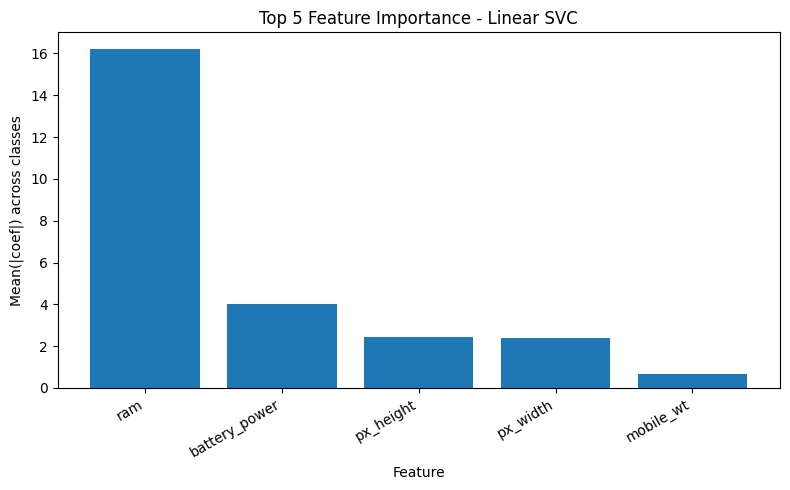

In [4]:
from sklearn.model_selection import GridSearchCV

# 1) GridSearchCV cho SVC
param_grid = {
    "C": [0.1, 1, 10, 100],
    "gamma": ["scale", "auto", 0.01, 0.1],
    "kernel": ["rbf", "linear"],
}

grid_search = GridSearchCV(
    estimator=SVC(probability=True),
    param_grid=param_grid,
    scoring="f1_weighted",
    cv=5,
    n_jobs=-1,
    verbose=1,
)

# 2) Fit trên tập train đã scale
grid_search.fit(X_train_scaled, y_train)

print("=== GridSearchCV Results ===")
print("Best params:", grid_search.best_params_)
print(f"Best CV F1 (weighted): {grid_search.best_score_:.4f}")

# 3) Đánh giá best_estimator_ trên test
best_model = grid_search.best_estimator_
y_test_pred_best = best_model.predict(X_test_scaled)

print("\n=== Best Model - Classification Report (Test) ===")
print(classification_report(y_test, y_test_pred_best, digits=4))

# 4) Feature importance từ coef_ (chỉ cho kernel='linear')
if getattr(best_model, "kernel", None) == "linear" and hasattr(best_model, "coef_"):
    # coef_ shape: (n_classes, n_features) cho bài toán đa lớp (one-vs-rest)
    coef_abs_mean = abs(best_model.coef_).mean(axis=0)

    feature_importance_df = pd.DataFrame(
        {
            "feature": X.columns,
            "importance": coef_abs_mean,
        }
    ).sort_values("importance", ascending=False)

    top5 = feature_importance_df.head(5)

    print("\n=== Top 5 features quan trọng nhất (linear SVC |mean(|coef|)|) ===")
    print(top5.to_string(index=False))

    plt.figure(figsize=(8, 5))
    plt.bar(top5["feature"], top5["importance"])
    plt.title("Top 5 Feature Importance - Linear SVC")
    plt.xlabel("Feature")
    plt.ylabel("Mean(|coef|) across classes")
    plt.xticks(rotation=30, ha="right")
    plt.tight_layout()
    plt.show()
else:
    print(
        "\nBest model không dùng kernel='linear' nên không có coef_ để phân tích feature importance."
    )

=== Random Forest - Classification Report (Test) ===
              precision    recall  f1-score   support

           0     0.9505    0.9600    0.9552       100
           1     0.8235    0.8400    0.8317       100
           2     0.8144    0.7900    0.8020       100
           3     0.9300    0.9300    0.9300       100

    accuracy                         0.8800       400
   macro avg     0.8796    0.8800    0.8797       400
weighted avg     0.8796    0.8800    0.8797       400



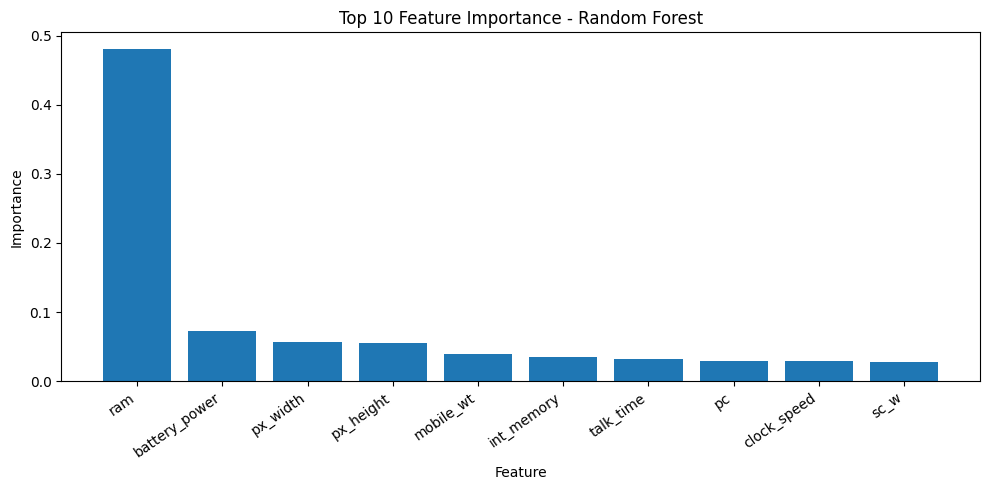

Saved: Y:\python\outputs\rf_feature_importance.png


In [5]:
# Random Forest: train, evaluate, feature importance
OUTPUT_DIR = ROOT / "outputs"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

rf_model = model.build_random_forest()
rf_model.fit(X_train_scaled, y_train)

rf_pred = rf_model.predict(X_test_scaled)
print("=== Random Forest - Classification Report (Test) ===")
print(classification_report(y_test, rf_pred, digits=4))

rf_importance_df = (
    pd.DataFrame({"feature": X.columns, "importance": rf_model.feature_importances_})
    .sort_values("importance", ascending=False)
    .head(10)
)

plt.figure(figsize=(10, 5))
plt.bar(rf_importance_df["feature"], rf_importance_df["importance"])
plt.title("Top 10 Feature Importance - Random Forest")
plt.xlabel("Feature")
plt.ylabel("Importance")
plt.xticks(rotation=35, ha="right")
plt.tight_layout()
rf_importance_path = OUTPUT_DIR / "rf_feature_importance.png"
plt.savefig(rf_importance_path, dpi=300, bbox_inches="tight")
plt.show()

print(f"Saved: {rf_importance_path}")

In [6]:
# Confusion Matrix + ROC for SVM and Random Forest
class_labels = ["Low", "Mid", "High", "Very High"]

# SVM (best model từ GridSearch)
y_pred_svm = best_model.predict(X_test_scaled)
evaluate.plot_confusion_matrix(
    y_test,
    y_pred_svm,
    labels=class_labels,
    save_path=OUTPUT_DIR / "svm_confusion_matrix.png",
)
evaluate.plot_roc_curve(
    best_model,
    X_test_scaled,
    y_test,
    save_path=OUTPUT_DIR / "svm_roc_curve.png",
)

# Random Forest
y_pred_rf = rf_model.predict(X_test_scaled)
evaluate.plot_confusion_matrix(
    y_test,
    y_pred_rf,
    labels=class_labels,
    save_path=OUTPUT_DIR / "rf_confusion_matrix.png",
)
evaluate.plot_roc_curve(
    rf_model,
    X_test_scaled,
    y_test,
    save_path=OUTPUT_DIR / "rf_roc_curve.png",
)

print("Saved:")
print(f"- {OUTPUT_DIR / 'svm_confusion_matrix.png'}")
print(f"- {OUTPUT_DIR / 'svm_roc_curve.png'}")
print(f"- {OUTPUT_DIR / 'rf_confusion_matrix.png'}")
print(f"- {OUTPUT_DIR / 'rf_roc_curve.png'}")

Macro-AUC (OvR): 0.9992
Macro-AUC (OvR): 0.9767
Saved:
- Y:\python\outputs\svm_confusion_matrix.png
- Y:\python\outputs\svm_roc_curve.png
- Y:\python\outputs\rf_confusion_matrix.png
- Y:\python\outputs\rf_roc_curve.png


In [7]:
# Learning Curve + Validation Curve (SVM)
svm_pipeline = model.build_svm_pipeline(
    C=getattr(best_model, "C", 1.0),
    kernel=getattr(best_model, "kernel", "rbf"),
    gamma=getattr(best_model, "gamma", "scale"),
)

evaluate.plot_learning_curve(
    svm_pipeline,
    X_train_scaled,
    y_train,
    save_path=OUTPUT_DIR / "svm_learning_curve.png",
)

evaluate.plot_validation_curve(
    X_train_scaled,
    y_train,
    param_name="clf__C",
    param_range=[0.01, 0.1, 1, 10, 100, 1000],
    save_path=OUTPUT_DIR / "svm_validation_curve_C.png",
)

print("Saved:")
print(f"- {OUTPUT_DIR / 'svm_learning_curve.png'}")
print(f"- {OUTPUT_DIR / 'svm_validation_curve_C.png'}")

Saved:
- Y:\python\outputs\svm_learning_curve.png
- Y:\python\outputs\svm_validation_curve_C.png


In [8]:
from pathlib import Path

import joblib

# Thư mục lưu artifacts
ARTIFACT_DIR = ROOT / "models"
ARTIFACT_DIR.mkdir(parents=True, exist_ok=True)

# 1) Lưu mô hình tốt nhất từ GridSearchCV
model_path = ARTIFACT_DIR / "best_svm_model.pkl"
joblib.dump(best_model, model_path)

# 2) Lưu scaler đã fit ở bước tiền xử lý
scaler_path = ARTIFACT_DIR / "scaler.pkl"
joblib.dump(scaler, scaler_path)

print("Da luu thanh cong:")
print(f"- Best model: {model_path}")
print(f"- Scaler    : {scaler_path}")

Da luu thanh cong:
- Best model: Y:\python\models\best_svm_model.pkl
- Scaler    : Y:\python\models\scaler.pkl


In [ ]:
import os
os.makedirs("../outputs", exist_ok=True)

from src.model import build_random_forest
from sklearn.metrics import classification_report
import matplotlib.pyplot as plt
import numpy as np

# Train RandomForest
rf_model = build_random_forest()
rf_model.fit(X_train_scaled, y_train)

# Predict and print classification report
y_pred_rf = rf_model.predict(X_test_scaled)
print("Random Forest Classification Report:")
print(classification_report(y_test, y_pred_rf, target_names=["Low", "Mid", "High", "Very High"]))

# Plot feature importances (top 10)
importances = rf_model.feature_importances_
indices = np.argsort(importances)[::-1][:10]

plt.figure(figsize=(10, 6))
plt.title("Top 10 Feature Importances - Random Forest")
plt.bar(range(10), importances[indices], align="center")
# If X is a DataFrame, use its columns for labels; otherwise, generic names
feature_names = [X.columns[i] if 'X' in globals() else f"Feature {i}" for i in indices]
plt.xticks(range(10), feature_names, rotation=45)
plt.tight_layout()
plt.savefig("../outputs/rf_feature_importance.png")
plt.show()

In [ ]:
from src.evaluate import plot_confusion_matrix, plot_roc_curve

# Confusion Matrix
print("Confusion Matrix - Best Model (SVM)")
# Check if y_pred_best is available, else predict
if 'y_pred_best' not in globals():
    try:
        y_pred_best = best_model.predict(X_test_scaled)
    except NameError:
        y_pred_best = y_pred # from baseline if best_model is not properly named, though user said best_model is defined
plot_confusion_matrix(y_test, best_model.predict(X_test_scaled), save_path="../outputs/svm_confusion_matrix.png")

print("Confusion Matrix - Random Forest")
plot_confusion_matrix(y_test, y_pred_rf, save_path="../outputs/rf_confusion_matrix.png")

# ROC Curve
print("ROC Curve - Best Model (SVM)")
plot_roc_curve(best_model, X_test_scaled, y_test, save_path="../outputs/svm_roc.png")

print("ROC Curve - Random Forest")
plot_roc_curve(rf_model, X_test_scaled, y_test, save_path="../outputs/rf_roc.png")

In [ ]:
from src.evaluate import plot_learning_curve, plot_validation_curve

print("Learning Curve - Best Model (SVM)")
plot_learning_curve(best_model, X_train_scaled, y_train, save_path="../outputs/svm_learning_curve.png")

print("Validation Curve - SVM")
plot_validation_curve(X_train_scaled, y_train, param_name="C", param_range=[0.01, 0.1, 1, 10, 100, 1000], save_path="../outputs/svm_validation_curve.png")